# Online Normalization (onorm)

[![Contributor Covenant](https://img.shields.io/badge/Contributor%20Covenant-2.1-4baaaa.svg)](code-of-conduct.md)
[![ci](https://github.com/ddimmery/onorm/actions/workflows/ci.yml/badge.svg)](https://github.com/ddimmery/onorm/actions/workflows/ci.yml)
![PyPI](https://img.shields.io/pypi/v/onorm)

`onorm` provides online (incremental) normalization algorithms for streaming data. These normalizers update their statistics incrementally without storing historical data, making them suitable for large-scale or real-time applications.

## Installation

```bash
pip install onorm
```

## Features

- **StandardScaler**: Online standardization (z-score normalization)
- **MinMaxScaler**: Online min-max scaling to [0, 1]
- **Winsorizer**: Online outlier clipping using quantiles
- **MultivariateNormalizer**: Online decorrelation and standardization
- **Pipeline**: Chain multiple normalizers sequentially

All normalizers support:

- Incremental updates via `partial_fit()`
- Transformation via `transform()`
- Combined operation via `partial_fit_transform()`
- State reset via `reset()`

## Usage Example

Let's compare online normalization with and without outlier handling. We'll process a stream of data points and track how well each approach maintains normalized statistics.

In [1]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
from onorm import Pipeline, StandardScaler, Winsorizer
from plotnine import aes, geom_line, geom_vline, ggplot, labs, theme, theme_minimal

rng = default_rng(2024)

In [2]:
# Generate streaming data with outliers
n_samples = 1000
n_dim = 5

X = rng.normal(loc=10, scale=1, size=(n_samples, n_dim))

# Add some outliers
outlier_indices = [100, 250, 500, 750]
for idx in outlier_indices:
    X[idx] = rng.uniform(-100, 100, size=n_dim)

print(f"Generated {n_samples} samples with {len(outlier_indices)} outliers")

Generated 1000 samples with 4 outliers


In [ ]:
# Approach 1: StandardScaler only (sensitive to outliers)
scaler_only = StandardScaler(n_dim=n_dim)

# Approach 2: Pipeline with Winsorizer + StandardScaler (robust to outliers)
pipeline = Pipeline([Winsorizer(n_dim=n_dim, clip_q=(0.05, 0.95)), StandardScaler(n_dim=n_dim)])

# Track mean estimates over time
scaler_means = []
pipeline_means = []

for x in X:
    scaler_only.partial_fit(x)
    pipeline.partial_fit(x)

    scaler_means.append(scaler_only.mean[0])
    pipeline_means.append(pipeline.normalizers[1].mean[0])

print(f"StandardScaler final mean: {scaler_only.mean[0]:.2f}")
print(f"Pipeline final mean: {pipeline.normalizers[1].mean[0]:.2f}")

StandardScaler final mean: 9.84
Pipeline final mean: 10.02


### Visualization

The plot shows how the estimated mean evolves as data streams in. The pipeline with winsorization maintains stable estimates when outliers appear (red lines), while the standard scaler is more affected by extreme values.

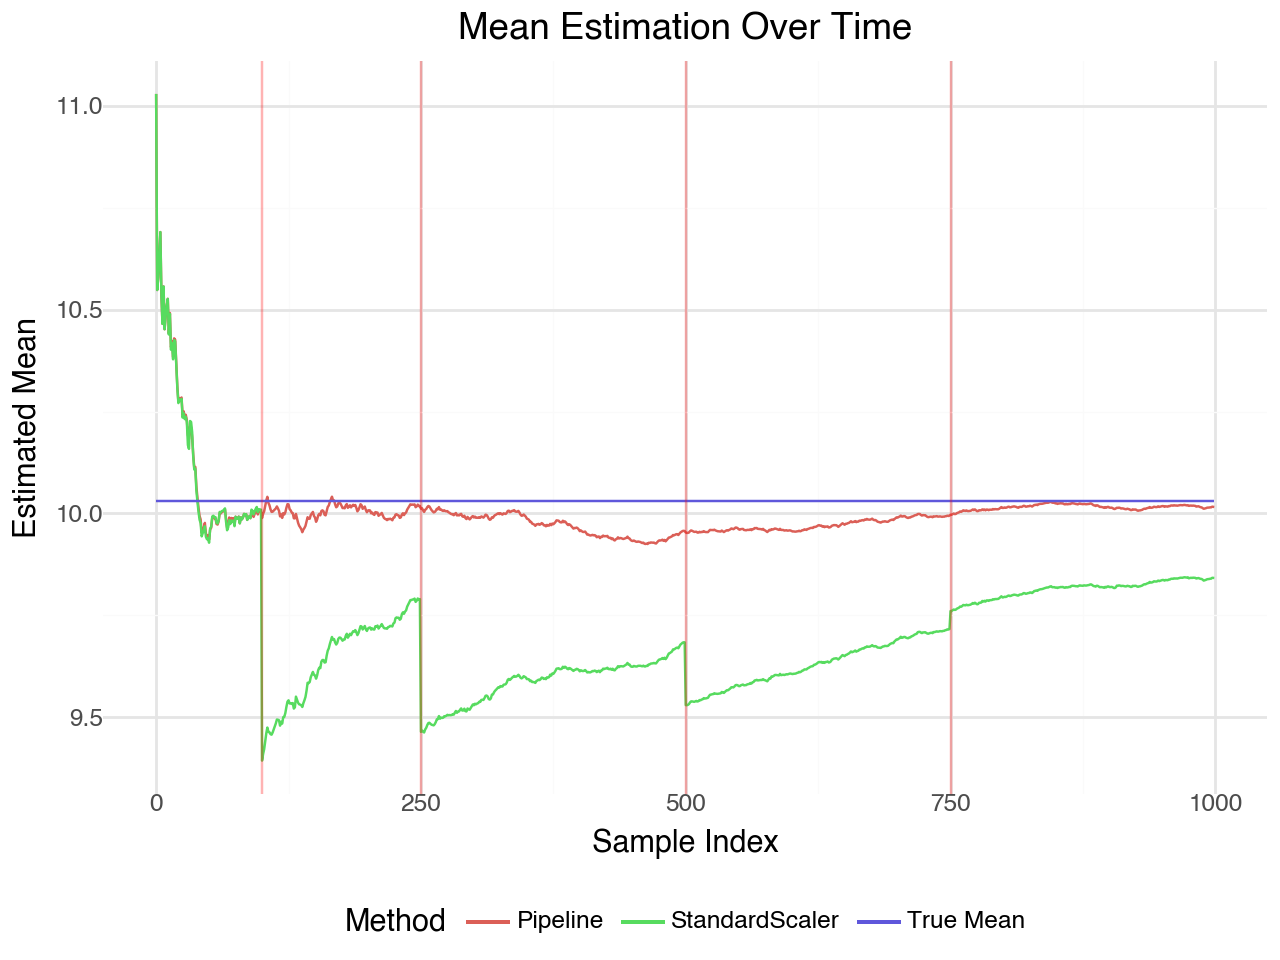

In [4]:
# Prepare data for plotting
true_mean = X[~np.isin(np.arange(len(X)), outlier_indices), 0].mean()

df = pd.DataFrame(
    {
        "Sample": range(n_samples),
        "StandardScaler": scaler_means,
        "Pipeline": pipeline_means,
        "True Mean": true_mean,
    }
)

df_long = pd.melt(df, id_vars=["Sample"], var_name="Method", value_name="Estimated Mean")

# Plot
(
    ggplot(df_long, aes(x="Sample", y="Estimated Mean", color="Method"))
    + geom_line()
    + geom_vline(xintercept=outlier_indices, color="red", alpha=0.3)
    + labs(title="Mean Estimation Over Time", x="Sample Index", y="Estimated Mean")
    + theme_minimal()
    + theme(legend_position="bottom")
)

### Key Takeaways

- **Online Learning**: All normalizers update incrementally without storing historical data
- **Robustness**: Use `Pipeline` with `Winsorizer` to handle outliers in streaming data
- **Efficiency**: Memory footprint remains constant regardless of stream length
- **Flexibility**: Mix and match normalizers to build custom preprocessing pipelines

For more details, see the [documentation](https://passexp.github.io/onorm/).